weather forcastor

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,FunctionTransformer,OneHotEncoder,PowerTransformer
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.metrics import r2_score,accuracy_score,classification_report,mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

import joblib
import warnings
warnings.filterwarnings("ignore")

Loading data

In [2]:
data=pd.read_csv("weather_classification_data.csv")
df=pd.DataFrame(data)
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


Cleaning data

In [3]:
df=df.dropna()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [4]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [5]:
df.corr(numeric_only=True)['Temperature'].sort_index(ascending=False)

Wind Speed             -0.070022
Visibility (km)         0.250751
UV Index                0.374773
Temperature             1.000000
Precipitation (%)      -0.287206
Humidity               -0.207969
Atmospheric Pressure    0.209188
Name: Temperature, dtype: float64

<Axes: >

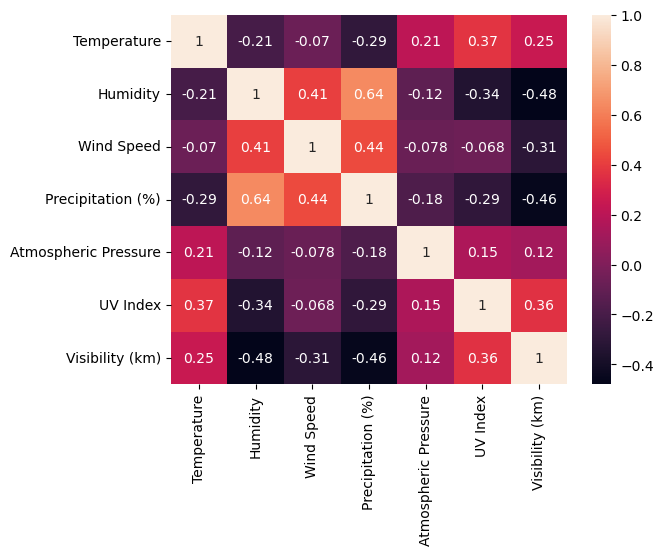

In [6]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

Checking outliers

In [7]:
num_features=df.select_dtypes(include='number')
Q1= num_features.quantile(0.25)
Q3= num_features.quantile(0.75)
IQR= Q3-Q1
lower_bound= Q1-1.5*IQR
upper_bound= Q3+1.5*IQR

outliers= (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Temperature              92
Humidity                  0
Wind Speed              404
Precipitation (%)         0
Atmospheric Pressure    927
UV Index                  0
Visibility (km)         383
dtype: int64


Cliping the outliers

In [8]:
df_capped = df.copy()

for col in num_features.columns:
    df_capped[col] = df_capped[col].clip(lower=lower_bound[col], upper=upper_bound[col])

# Verify that 0 outliers remain
num_features_capped = df_capped.select_dtypes(include='number')
outliers_check = (num_features_capped < lower_bound) | (num_features_capped > upper_bound)
print("Remaining outliers per column:")
print(outliers_check.sum())

Remaining outliers per column:
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Atmospheric Pressure    0
UV Index                0
Visibility (km)         0
dtype: int64


In [9]:
num_cols= df_capped.select_dtypes(include='number')
num_cols.skew()

Temperature             0.064840
Humidity               -0.401614
Wind Speed              0.677507
Precipitation (%)      -0.152457
Atmospheric Pressure   -0.117786
UV Index                0.900010
Visibility (km)         0.724154
dtype: float64

In [10]:
df_capped.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')

Split X and y

In [11]:
#prediction for temperature
left_skewed_cols=['Humidity','Precipitation (%)','Atmospheric Pressure']
right_skewed_cols=['Wind Speed','UV Index','Visibility (km)']
other_numeric_cols=[]
oridinal_cols= ['Cloud Cover','Season','Location']
feature_cols= left_skewed_cols+right_skewed_cols+other_numeric_cols+oridinal_cols
X= df_capped[feature_cols]
y=df_capped['Temperature']

#prediction for weather type
y2= df_capped['Weather Type']


Train test spliting

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

X2_train,X2_test,y2_train,y2_test=train_test_split(X,y2,random_state=42,test_size=0.3)

Preprocessing using columntransformer

In [13]:
left_skew_pipeline= Pipeline(steps=[
    ('letf_skew',PowerTransformer(method='yeo-johnson')),
    ('scale',StandardScaler())
])

right_skew_pipeline= Pipeline(steps=[
    ('right_skew',FunctionTransformer(np.log1p)),
    ('scale',StandardScaler())
])

oridinal_pipeline= Pipeline(steps=[
    ('impute', SimpleImputer(strategy="most_frequent")),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor= ColumnTransformer(transformers=[
    ('left_skew_pipeline',left_skew_pipeline,left_skewed_cols),
    ('right_skew_pipeline',right_skew_pipeline,right_skewed_cols),
    ('oridinal_pipeline',oridinal_pipeline,oridinal_cols)
])
preprocessor

,transformers,"[('left_skew_pipeline', ...), ('right_skew_pipeline', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,method,'yeo-johnson'
,standardize,True
,copy,True


random forest models

In [14]:
rf_pipeline_regression= Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('ramdom_forest_regression',RandomForestRegressor())
])

rf_pipeline_regression.fit(X_train,y_train)
rf_regression_pred= rf_pipeline_regression.predict(X_test)
print(f"Accuracy of regression: {r2_score(y_test,rf_regression_pred)}")

rf_pipeline_classification= Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('random_forest_classifier',RandomForestClassifier())
])
rf_pipeline_classification.fit(X2_train,y2_train)
rf_classification_pred= rf_pipeline_classification.predict(X2_test)
print(f"Accuracy of classification: {r2_score(y_test,rf_regression_pred)}")

Accuracy of regression: 0.5905847477374122
Accuracy of classification: 0.5905847477374122


Hyper parameter tunning of random forest models

In [15]:
param_grid= {
    'ramdom_forest_regression__n_estimators': [100,200,300],
    'ramdom_forest_regression__max_depth': [5,10,15],
    'ramdom_forest_regression__min_samples_split': [2,5,10],
    'ramdom_forest_regression__min_samples_leaf': [1,2,4]
}

random_search_regression= RandomizedSearchCV(
    estimator=rf_pipeline_regression,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search_regression.fit(X_train,y_train)

,estimator,Pipeline(step...Regressor())])
,param_distributions,"{'ramdom_forest_regression__max_depth': [5, 10, ...], 'ramdom_forest_regression__min_samples_leaf': [1, 2, ...], 'ramdom_forest_regression__min_samples_split': [2, 5, ...], 'ramdom_forest_regression__n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [16]:
random_search_regression.best_params_

{'ramdom_forest_regression__n_estimators': 300,
 'ramdom_forest_regression__min_samples_split': 10,
 'ramdom_forest_regression__min_samples_leaf': 1,
 'ramdom_forest_regression__max_depth': 10}

In [17]:
rf_best_pipeline_regression= random_search_regression.best_estimator_
rf_best_preds_regression= rf_best_pipeline_regression.predict(X_test)

print(f"R2: {r2_score(y_test,rf_best_preds_regression)}")
print(f"MAE: {mean_absolute_error(y_test,rf_best_preds_regression)}")

R2: 0.6022116417195362
MAE: 7.897950496566393


In [18]:
param_grid= {
    'random_forest_classifier__n_estimators': [100,200,300],
    'random_forest_classifier__max_depth': [5,10,15],
    'random_forest_classifier__min_samples_split': [2,5,10],
    'random_forest_classifier__min_samples_leaf': [1,2,4]
}

random_search_classification= RandomizedSearchCV(
    estimator=rf_pipeline_classification,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search_classification.fit(X2_train,y2_train)

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'random_forest_classifier__max_depth': [5, 10, ...], 'random_forest_classifier__min_samples_leaf': [1, 2, ...], 'random_forest_classifier__min_samples_split': [2, 5, ...], 'random_forest_classifier__n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [19]:
random_search_classification.best_params_

{'random_forest_classifier__n_estimators': 200,
 'random_forest_classifier__min_samples_split': 10,
 'random_forest_classifier__min_samples_leaf': 2,
 'random_forest_classifier__max_depth': 15}

In [20]:
rf_best_pipeline_classification= random_search_classification.best_estimator_
rf_best_preds_classification= rf_best_pipeline_classification.predict(X2_test)

print(f"Accuracy: {accuracy_score(y2_test,rf_best_preds_classification)}")
print(f"MAE: {classification_report(y2_test,rf_best_preds_classification)}")

Accuracy: 0.906060606060606
MAE:               precision    recall  f1-score   support

      Cloudy       0.87      0.90      0.89       955
       Rainy       0.89      0.88      0.89       982
       Snowy       0.91      0.94      0.92      1033
       Sunny       0.94      0.90      0.92       990

    accuracy                           0.91      3960
   macro avg       0.91      0.91      0.91      3960
weighted avg       0.91      0.91      0.91      3960



random forest classification (actual vs predictions)

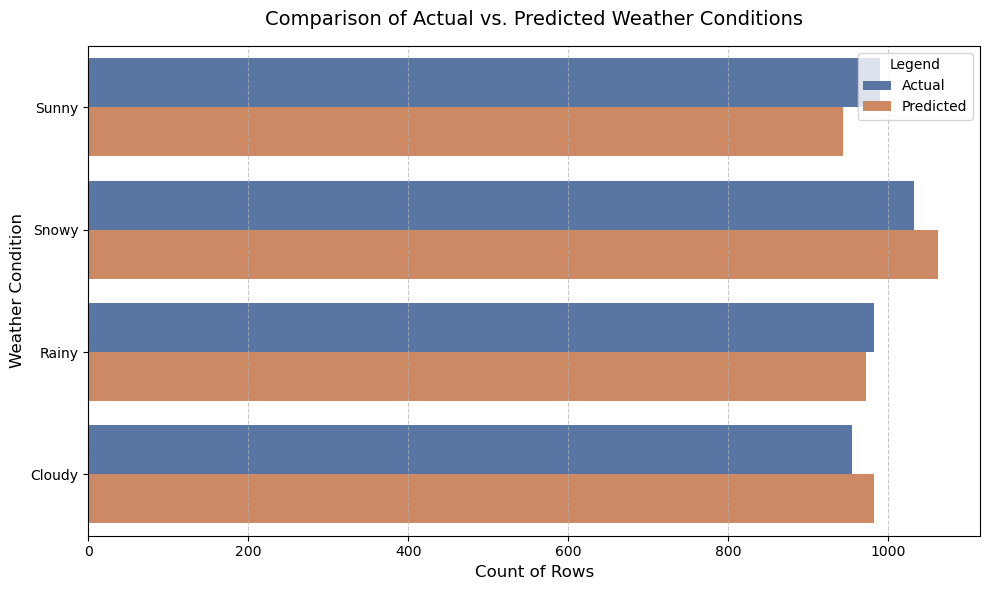

In [21]:
result = pd.DataFrame({
    "Actual": y2_test.values,
    "Predicted": rf_best_preds_classification
})

# 2. Transform the data so Seaborn can easily plot both side-by-side
# This converts columns into a "Long-form" format suitable for 'hue'
result_melted = result.melt(value_name="Weather Condition", var_name="Type")

# 3. Create a clean, professional visualization
plt.figure(figsize=(10, 6))

sns.countplot(
    data=result_melted, 
    y="Weather Condition", 
    hue="Type", 
    palette=["#4C72B0", "#DD8452"]  # Professional blue and orange shades
)

# Styling details for readability
plt.title("Comparison of Actual vs. Predicted Weather Conditions", fontsize=14, pad=15)
plt.xlabel("Count of Rows", fontsize=12)
plt.ylabel("Weather Condition", fontsize=12)
plt.legend(title="Legend")
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Clear horizontal scanning grid

plt.tight_layout()
plt.show()

random forest regression (actual vs predictions)

   Actual  Predicted
0    23.0  31.071153
1    62.0  46.697013
2    40.0  32.105264
3    -7.0  -2.109864
4    21.0  38.403215


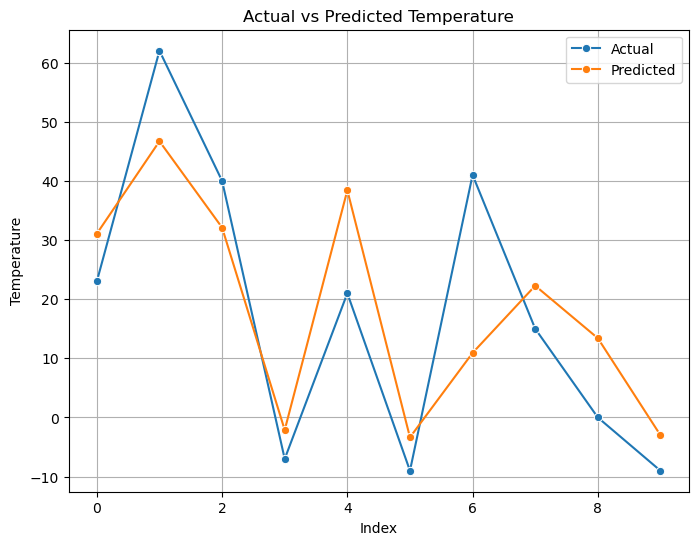

In [22]:
result2=pd.DataFrame({
    "Actual": y_test.values,
    'Predicted': rf_best_preds_regression
})

print(result2.head())
result2=result2.head(10)

plt.figure(figsize=(8,6))
sns.lineplot(data=result2,x=result2.index,y='Actual',label="Actual",marker="o")
sns.lineplot(data=result2,x=result2.index,y="Predicted",label="Predicted",marker="o")
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Index")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
feature_cols

['Humidity',
 'Precipitation (%)',
 'Atmospheric Pressure',
 'Wind Speed',
 'UV Index',
 'Visibility (km)',
 'Cloud Cover',
 'Season',
 'Location']

Inputs

In [24]:
try:
    humidity = int(input("Enter Humidity: "))
    precipitation = float(input("Enter Precipitation (%): "))
    Atmospheric_Pressure= float(input("Enter Atmospheric Pressure: "))
    windSpeed = float(input("Enter Wind Speed: "))
    uvIndex = int(input("Enter UV Index: "))
    visibility = float(input("Enter Visibility (km): "))
    
    cloudCover = input(
        "Enter Cloud Cover (partly cloudy/clear/overcast/cloudy): "
    ).lower()

    season = input(
        "Enter Season (winter/spring/autumn/summer): "
    ).lower()


    location = input(
        "Enter Location (inland/mountain/coastal): "
    ).lower()

    userinput = pd.DataFrame([[
        humidity,
        precipitation,
        Atmospheric_Pressure,
        windSpeed,
        uvIndex,
        visibility,
        cloudCover,
        season,
        location
    ]], columns=feature_cols)

    output1 = rf_best_pipeline_regression.predict(userinput)
    output2 = rf_best_pipeline_classification.predict(userinput)


    print(f"Predicted Weather Type: {output2}")
    print(f"Predicted Temperature: {round(output1[0], 2)} °C")

except Exception as e:
    print("An error occurred:", e)

Predicted Weather Type: ['Rainy']
Predicted Temperature: 22.43 °C


In [25]:
joblib.dump(rf_best_pipeline_regression,"random_forest_regression.pkl")
joblib.dump(rf_best_pipeline_classification,'random_forest_classification.pkl')

['random_forest_classification.pkl']